In [15]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv
from ipywidgets import interact
import ipywidgets as widgets
from ipywidgets import interact, IntSlider, FloatSlider

In [17]:
# Generate synthetic data
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X**2 + np.random.randn(100, 1)*1e-1

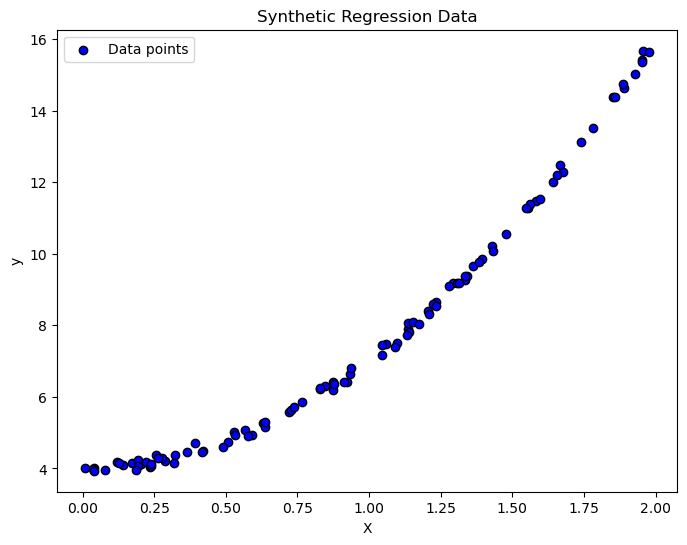

In [19]:
# Plotting the generated data
plt.figure(figsize=(8, 6))  # Set the figure size for the plot
plt.scatter(X, y, color='blue', edgecolor='k', label='Data points')  # Plot the data points
plt.title('Synthetic Regression Data')  # Title of the plot
plt.xlabel('X')  # Label for the x-axis
plt.ylabel('y')  # Label for the y-axis
plt.legend()  # Add a legend
plt.show()  # Display the plot

## Closed Form Ridge Regression from scratch

interactive(children=(FloatSlider(value=1.0, description='Noise level:', max=5.0), FloatSlider(value=1.0, desc…


Parameters: Noise = 1.00, Lambda = 0.00
Intercept (θ₀): 2.1103
Slope (θ₁): 5.6746
RMSE: 1.3943



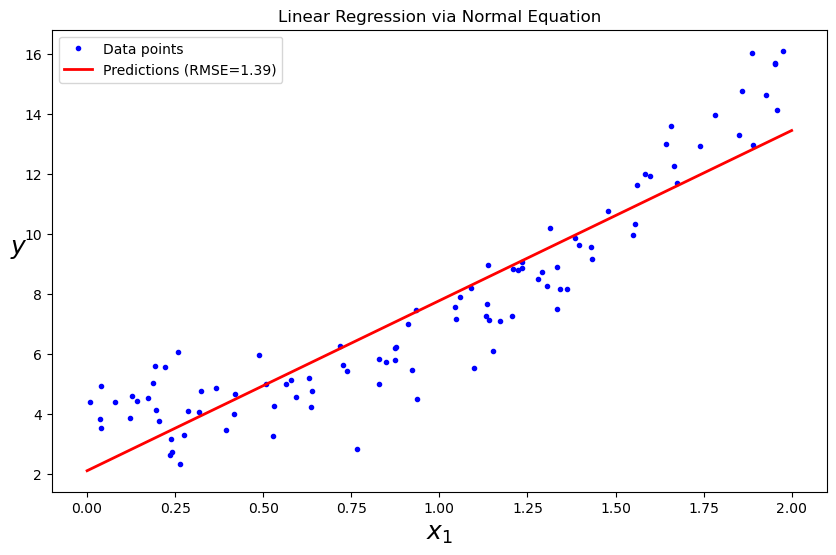


Parameters: Noise = 2.00, Lambda = 10.00
Intercept (θ₀): 3.3274
Slope (θ₁): 4.4287
RMSE: 2.3524



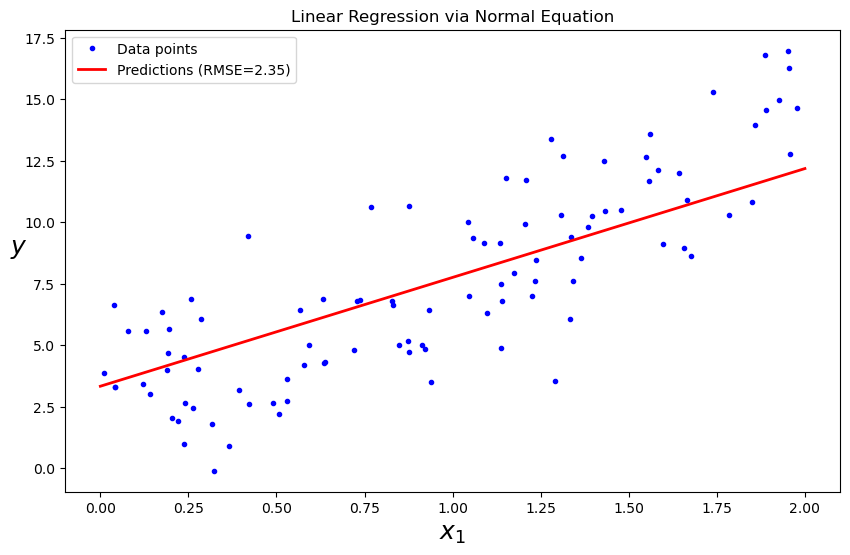


Parameters: Noise = 0.50, Lambda = 50.00
Intercept (θ₀): 5.5062
Slope (θ₁): 2.2918
RMSE: 2.2080



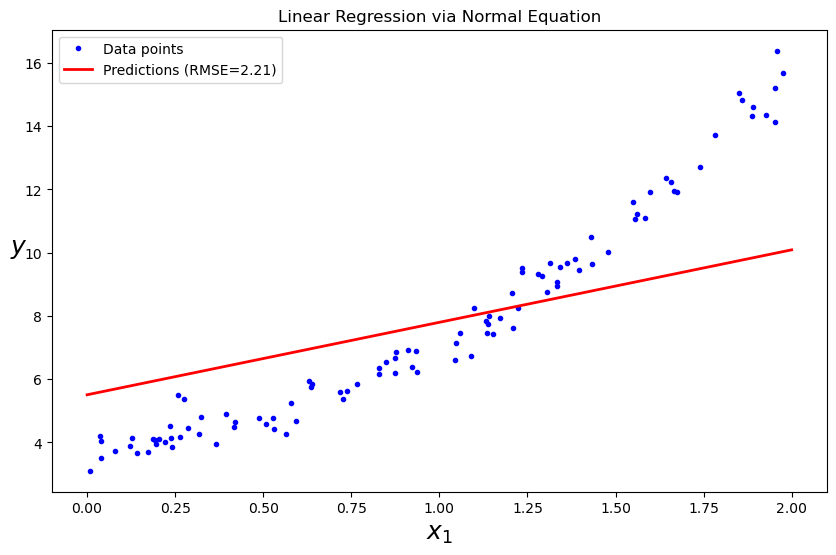

In [28]:
from sklearn.metrics import mean_squared_error
# Augmenting the feature matrix X with an additional column of ones for the intercept
X_b = np.c_[np.ones((100, 1)), X]  # Add x0 = 1 to each instance for the bias term
def plot_regression_closed_form(noise=1.0, lambda_=1.0):
    # Modify the target values by adding Gaussian noise
    y_noisy = y + np.random.randn(100, 1) * noise  # Add noise to the original target data
    
    # Set the regularization parameter lambda
    I = np.eye(2)
    I[0, 0] = 0  # Do not regularize the intercept term
    # Closed-form solution (Normal Equation) to find the best fitting parameters
    theta_best = inv(X_b.T.dot(X_b) + lambda_ * I).dot(X_b.T).dot(y_noisy)  # Normal equation
    
    # Print parameters
    print(f"\n{'='*60}")
    print(f"Parameters: Noise = {noise:.2f}, Lambda = {lambda_:.2f}")
    print(f"Intercept (θ₀): {theta_best[0][0]:.4f}")
    print(f"Slope (θ₁): {theta_best[1][0]:.4f}")
    
    # Make predictions for new data points
    X_new = np.array([[0], [2]])  # New data points for prediction
    X_new_b = np.c_[np.ones((2, 1)), X_new]  # Add the intercept term for new data points
    y_predict = X_new_b.dot(theta_best)  # Predictions using the normal equation
    
    # Calculate RMSE
    y_pred = X_b.dot(theta_best)
    rmse = np.sqrt(mean_squared_error(y_noisy, y_pred))
    print(f"RMSE: {rmse:.4f}")
    print(f"{'='*60}\n")
    
    # Plotting the results
    plt.figure(figsize=(10, 6))
    plt.plot(X, y_noisy, "b.", label='Data points')  # Plot noisy data points
    plt.plot(X_new, y_predict, "r-", linewidth=2, label=f"Predictions (RMSE={rmse:.2f})")  # Plot the regression line
    plt.xlabel("$x_1$", fontsize=18)  # Label for the x-axis
    plt.ylabel("$y$", rotation=0, fontsize=18)  # Label for the y-axis
    plt.title("Linear Regression via Normal Equation")  # Title of the plot
    plt.legend()  # Show legend
    plt.show()  # Display the plot

# Sliders for noise level and lambda variations in the interactive plot
interact(plot_regression_closed_form, 
         noise=FloatSlider(value=1.0, min=0.0, max=5.0, step=0.1, description='Noise level:'),
         lambda_=FloatSlider(value=1.0, min=0.0, max=100.0, step=0.1, description='Lambda:'))

plot_regression_closed_form(noise=1.0, lambda_=0.0)
plot_regression_closed_form(noise=2.0, lambda_=10.0)
plot_regression_closed_form(noise=0.5, lambda_=50.0)

### Closed-form Solution

This demonstrates how to implement a linear regression using the closed-form solution, also known as the Normal Equation, with the addition of L2 regularization (Ridge Regression). 

The purpose of this demonstration is to show the impact of noise and regularization on the model's performance, particularly how they affect the Root Mean Squared Error (RMSE) of the predictions.

#### Key Components of the Script

- **Feature Augmentation**: Adds a column of ones to the feature matrix `X` to account for the intercept in the linear model. This modification allows the linear model to fit not just a slope but also an intercept.

- **Noise Addition**: Allows for the interactive adjustment of the level of Gaussian noise added to the target variable `y`. This feature demonstrates how model accuracy degrades as noise increases.

- **Regularization Setup**: Incorporates an L2 penalty (Ridge) into the Normal Equation through the regularization parameter `lambda_`. Regularization helps in reducing overfitting, particularly in scenarios where the model might otherwise fit excessively to noise in the data.

- **Normal Equation with Regularization**: Computes the optimal coefficients (`theta_best`) by minimizing a cost function augmented with a regularization term. This term penalizes large values of the coefficients, promoting simpler model structures.

## Comparision between Ridge and Lasso using Sklearn

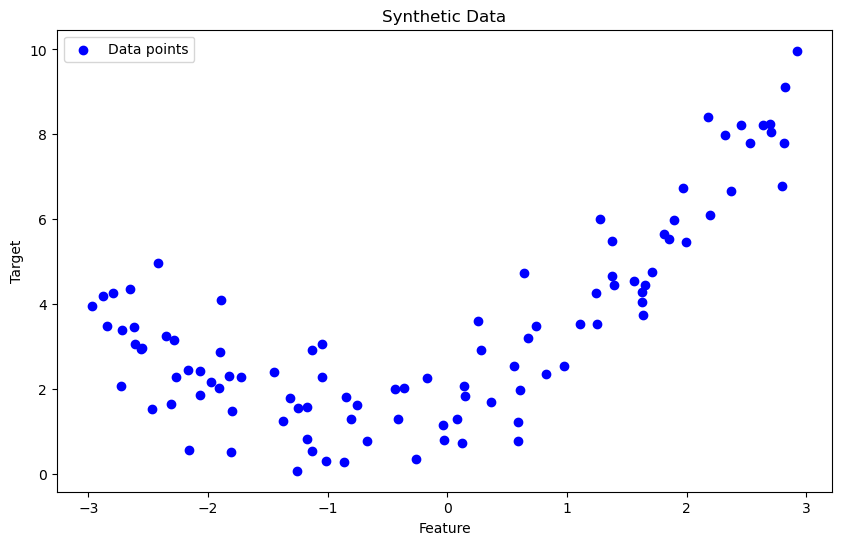

In [32]:
from sklearn.linear_model import Ridge, Lasso  # Importing Ridge and Lasso regression models from sklearn
from sklearn.preprocessing import PolynomialFeatures  # Importing tool to generate polynomial and interaction features
from sklearn.pipeline import make_pipeline  # Importing utility to create a pipeline for streamlined workflows


# Set the random seed for reproducibility
np.random.seed(42)

# Generating synthetic data
X = np.random.rand(100, 1) * 6 - 3  # Creating a feature array with random values scaled to range -3 to 3
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1)  # Generating the target variable with a quadratic relationship and added noise

# Augmenting the feature matrix X with polynomial features to increase model complexity
poly_features = PolynomialFeatures(degree=10, include_bias=False)  # Creating an instance to transform the feature set to include polynomial terms up to degree 10
X_poly = poly_features.fit_transform(X)  # Applying the transformation to the feature set

# Plotting the dataset to visualize the relationship and variance
plt.figure(figsize=(10, 6))  # Setting the figure size
plt.scatter(X, y, color='blue', label='Data points')  # Plotting the data points
plt.xlabel('Feature')  # Labeling the x-axis
plt.ylabel('Target')  # Labeling the y-axis
plt.title('Synthetic Data')  # Setting the title of the plot
plt.legend()  # Displaying the legend
plt.show()  # Displaying the plot


interactive(children=(FloatSlider(value=1.0, description='lambda_ridge', max=1000.0), FloatSlider(value=0.1, d…


Parameters: Lambda Ridge = 0.50, Lambda Lasso = 0.10
Ridge RMSE: 0.8635
Lasso RMSE: 0.9038



/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.395e+00, tolerance: 5.269e-02
  model = cd_fast.enet_coordinate_descent(


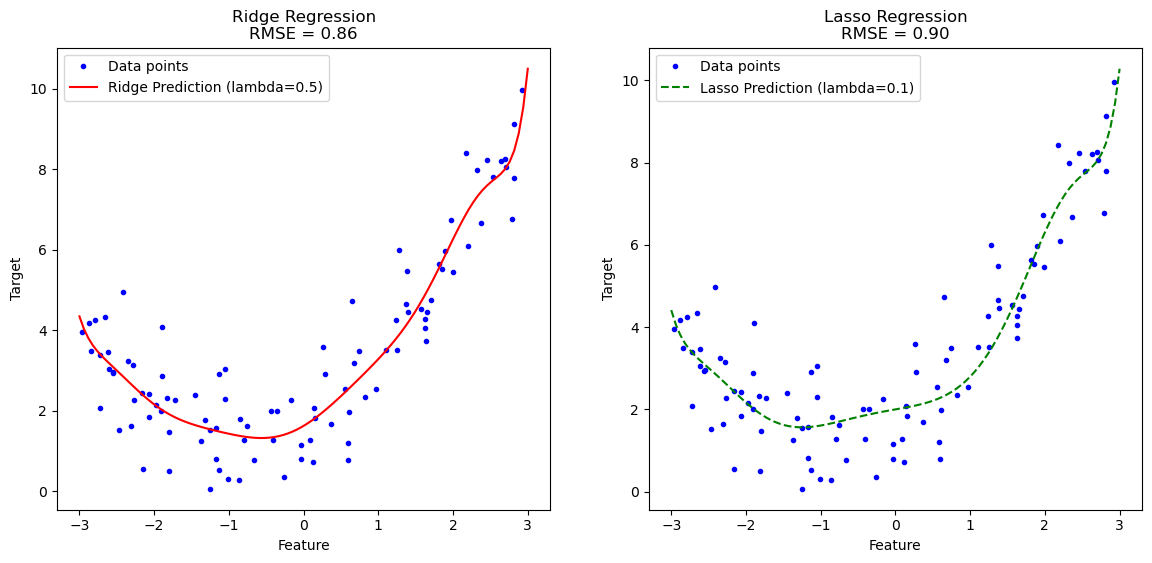


Parameters: Lambda Ridge = 10.00, Lambda Lasso = 1.00
Ridge RMSE: 0.8856
Lasso RMSE: 1.1329



/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.587e+00, tolerance: 5.269e-02
  model = cd_fast.enet_coordinate_descent(


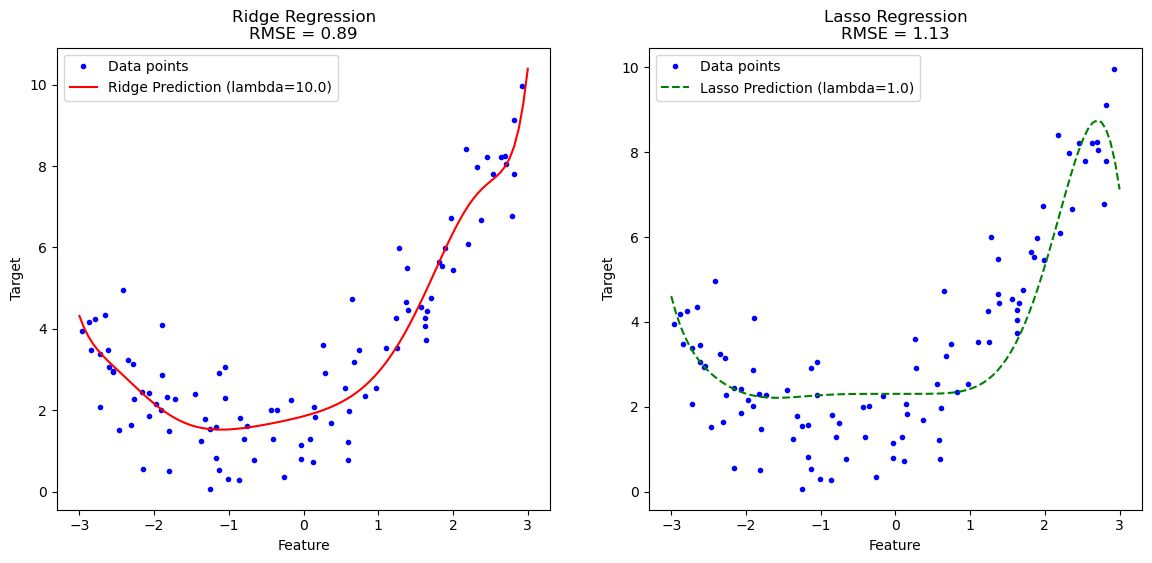


Parameters: Lambda Ridge = 100.00, Lambda Lasso = 5.00
Ridge RMSE: 0.9320
Lasso RMSE: 1.3258



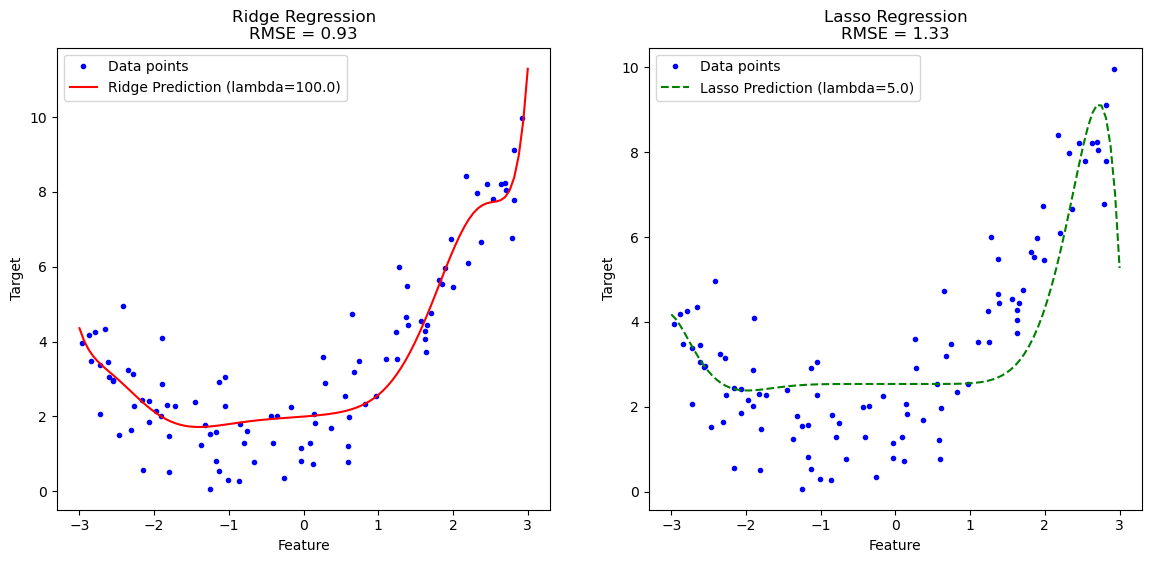

In [36]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features
poly_features = PolynomialFeatures(degree=10, include_bias=False)
X_poly = poly_features.fit_transform(X)

def train_and_visualize_ridge_lasso(lambda_ridge=0.5, lambda_lasso=0.1):
    """
    Trains Ridge and Lasso regression models on polynomial features and visualizes their predictions.
    """
    # Print parameters
    print(f"\n{'='*60}")
    print(f"Parameters: Lambda Ridge = {lambda_ridge:.2f}, Lambda Lasso = {lambda_lasso:.2f}")
    print(f"{'='*60}")
    
    # Create Ridge and Lasso models with specified lambda values
    ridge_model = Ridge(alpha=lambda_ridge)
    lasso_model = Lasso(alpha=lambda_lasso, max_iter=10000)
    # Fit models to the polynomially transformed features
    ridge_model.fit(X_poly, y)
    lasso_model.fit(X_poly, y)
    
    # Prepare a range of feature values for making predictions
    X_new = np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly_features.transform(X_new)
    
    # Predict using both models
    y_ridge_pred = ridge_model.predict(X_new_poly)
    y_lasso_pred = lasso_model.predict(X_new_poly)
    
    # Calculate RMSE for each model
    rmse_ridge = np.sqrt(mean_squared_error(y, ridge_model.predict(X_poly)))
    rmse_lasso = np.sqrt(mean_squared_error(y, lasso_model.predict(X_poly)))
    
    print(f"Ridge RMSE: {rmse_ridge:.4f}")
    print(f"Lasso RMSE: {rmse_lasso:.4f}")
    print(f"{'='*60}\n")
    
    # Plot results in two subplots
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.plot(X, y, "b.", label='Data points')
    plt.plot(X_new, y_ridge_pred, "r-", label=f"Ridge Prediction (lambda={lambda_ridge})")
    plt.xlabel('Feature')
    plt.ylabel('Target')
    plt.title(f'Ridge Regression\nRMSE = {rmse_ridge:.2f}')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(X, y, "b.", label='Data points')
    plt.plot(X_new, y_lasso_pred, "g--", label=f"Lasso Prediction (lambda={lambda_lasso})")
    plt.xlabel('Feature')
    plt.ylabel('Target')
    plt.title(f'Lasso Regression\nRMSE = {rmse_lasso:.2f}')
    plt.legend()
    plt.show()

# Widgets for interactive lambda adjustments
interact(train_and_visualize_ridge_lasso, 
         lambda_ridge=FloatSlider(min=0, max=1000, step=0.1, value=1),
         lambda_lasso=FloatSlider(min=0, max=10, step=0.01, value=0.1))

train_and_visualize_ridge_lasso(lambda_ridge=0.5, lambda_lasso=0.1)
train_and_visualize_ridge_lasso(lambda_ridge=10.0, lambda_lasso=1.0)
train_and_visualize_ridge_lasso(lambda_ridge=100.0, lambda_lasso=5.0)

### Ridge vs Lasso Regression

This is  to demonstrate the effect of Ridge and Lasso regression techniques on polynomially transformed features. It allows interactive manipulation of the regularization strength (`lambda`) parameters to observe their impact on model performance measured by Root Mean Squared Error (RMSE).

#### Features

- **Ridge and Lasso Regression Models**:
  - **Ridge Regression**: Minimizes a penalized residual sum of squares where the penalty is proportional to the square of the magnitude of the coefficients. Helps in reducing model complexity and multicollinearity.
  - **Lasso Regression**: Introduces sparsity into the coefficient estimates leading to some coefficients being set to zero. Excellent for feature selection in models with numerous features.

- **RMSE Calculation**:
  - Computes the RMSE for both models as a measure of the prediction error. Lower RMSE values indicate better fitting models.

- **Plotting**:
  - Visual comparison of predictions from both models against the actual data points. Each model's plot includes its prediction line and the corresponding RMSE, providing a direct visual and quantitative assessment of each model's accuracy.

- **Interactive Widgets**:
  - Two sliders allow the user to dynamically adjust the `lambda` values for both Ridge and Lasso models and immediately see the effect on the model predictions and RMSE. This interaction aids in understanding the trade-off between bias and variance and how regularization can mitigate overfitting.